# ACL Tear Detection - Combined Dataset Training

**Key improvements:**
1. **Combined dataset** with 1,202 samples (was 466)
2. **Balanced classes**: Normal=576, Partial=286, Complete=340
3. **MRI-specific normalization** (per-image)
4. **CrossEntropyLoss** with class weights
5. **More trainable layers** for medical domain adaptation

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Configuration - UPDATED FOR COMBINED DATASET
DATA_DIR = '/content/drive/MyDrive/combined'

# Training settings
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 3  # 0: Normal, 1: Partial, 2: Complete
CENTER_SLICES = 20  # Use center N slices (ACL region)
RANDOM_SEED = 42

# Use per-image normalization (recommended for MRI)
USE_PER_IMAGE_NORM = True

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Load metadata
data_path = Path(DATA_DIR)
metadata = pd.read_csv(data_path / 'metadata.csv')

print(f"Total patients: {len(metadata)}")
print(f"\nLabel distribution:")
print(metadata['label_name'].value_counts())

# Check class balance
class_counts_df = metadata['label'].value_counts().sort_index()
imbalance_ratio = class_counts_df.max() / class_counts_df.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.1f}x")

# Show source distribution
if 'source' in metadata.columns:
    print(f"\nSource distribution:")
    print(metadata['source'].value_counts())

Total patients: 1202

Label distribution:
label_name
NORMAL         576
COMPLETE       295
PARTIAL_ACL    144
PARTIAL        142
ACL             45
Name: count, dtype: int64

Class imbalance ratio: 2.0x

Source distribution:
source
MRI               736
Priyank_Saxena    466
Name: count, dtype: int64


In [5]:
# Split data: patient-level split to avoid data leakage
train_df, temp_df = train_test_split(
    metadata, test_size=0.3, stratify=metadata['label'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=RANDOM_SEED
)

print(f"Train: {len(train_df)} patients")
print(f"Val: {len(val_df)} patients")
print(f"Test: {len(test_df)} patients")

print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())

Train: 841 patients
Val: 180 patients
Test: 181 patients

Train label distribution:
label
0    403
1    200
2    238
Name: count, dtype: int64


In [13]:
class ACLSliceDataset(Dataset):
    """
    Dataset that treats each slice as a separate sample.
    Uses per-image normalization for MRI data.
    """
    def __init__(self, df, data_dir, transform=None, center_slices=20):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.center_slices = center_slices

        # Pre-compute slice indices
        self.samples = []
        for idx, row in self.df.iterrows():
            num_slices = int(row['num_slices'])
            start = max(0, (num_slices - center_slices) // 2)
            end = min(num_slices, start + center_slices)
            for slice_idx in range(start, end):
                self.samples.append((idx, slice_idx, int(row['label'])))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patient_idx, slice_idx, label = self.samples[idx]
        row = self.df.iloc[patient_idx]

        # Load volume
        file_path = self.data_dir / row['filename']
        volume = np.load(file_path)['data']

        # Clamp slice_idx to valid range (in case metadata num_slices doesn't match actual volume)
        slice_idx = min(slice_idx, volume.shape[0] - 1)

        # Get slice and normalize to 0-1
        img = volume[slice_idx].astype(np.float32) / 255.0

        # Per-image normalization (KEY FIX for MRI)
        img_mean = img.mean()
        img_std = img.std() + 1e-8
        img = (img - img_mean) / img_std

        # Convert to 3-channel for pretrained models
        img = np.stack([img, img, img], axis=0)
        img = torch.from_numpy(img)

        if self.transform:
            img = self.transform(img)

        return img, label, patient_idx

    def get_labels(self):
        return [s[2] for s in self.samples]

In [14]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

val_transform = None

# Create datasets
train_dataset = ACLSliceDataset(train_df, DATA_DIR, train_transform, CENTER_SLICES)
val_dataset = ACLSliceDataset(val_df, DATA_DIR, val_transform, CENTER_SLICES)
test_dataset = ACLSliceDataset(test_df, DATA_DIR, val_transform, CENTER_SLICES)

print(f"Train samples (slices): {len(train_dataset)}")
print(f"Val samples (slices): {len(val_dataset)}")
print(f"Test samples (slices): {len(test_dataset)}")

Train samples (slices): 16820
Val samples (slices): 3600
Test samples (slices): 3620


In [15]:
# Create weighted sampler for balanced training
train_labels = train_dataset.get_labels()
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

print(f"Class counts in training: {class_counts}")
print(f"Class weights: {class_weights}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Class counts in training: [8060 4000 4760]
Class weights: [0.00012407 0.00025    0.00021008]


In [16]:
# Model: EfficientNet-B0 with more trainable layers
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Freeze only first 50% of layers (more adaptation for MRI)
all_params = list(model.features.parameters())
freeze_until = len(all_params) // 2
for i, param in enumerate(all_params):
    param.requires_grad = (i >= freeze_until)

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable parameters: 3,989,195 / 4,336,255 (92.0%)


In [17]:
# Loss function with class weights
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

In [18]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels, _) in enumerate(tqdm(loader, desc='Training')):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels

In [19]:
# Training loop with early stopping
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
patience = 10
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/dataset/best_acl_model_combined.pth')
        print(f"  -> Saved best model (val_acc: {val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Training:   0%|          | 0/526 [00:00<?, ?it/s]

Epoch 1/50
  Train Loss: 0.8655 | Train Acc: 55.23%
  Val Loss: 0.8264 | Val Acc: 62.61%
  -> Saved best model (val_acc: 62.61%)


Training:   0%|          | 0/526 [00:00<?, ?it/s]

Epoch 2/50
  Train Loss: 0.7927 | Train Acc: 60.48%
  Val Loss: 0.8054 | Val Acc: 65.44%
  -> Saved best model (val_acc: 65.44%)


Training:   0%|          | 0/526 [00:00<?, ?it/s]

...

Training:   0%|          | 0/526 [00:00<?, ?it/s]

Epoch 10/50
  Train Loss: 0.5418 | Train Acc: 76.17%
  Val Loss: 0.9305 | Val Acc: 65.78%


Training:   0%|          | 0/526 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b44f69a72e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

KeyboardInterrupt: 

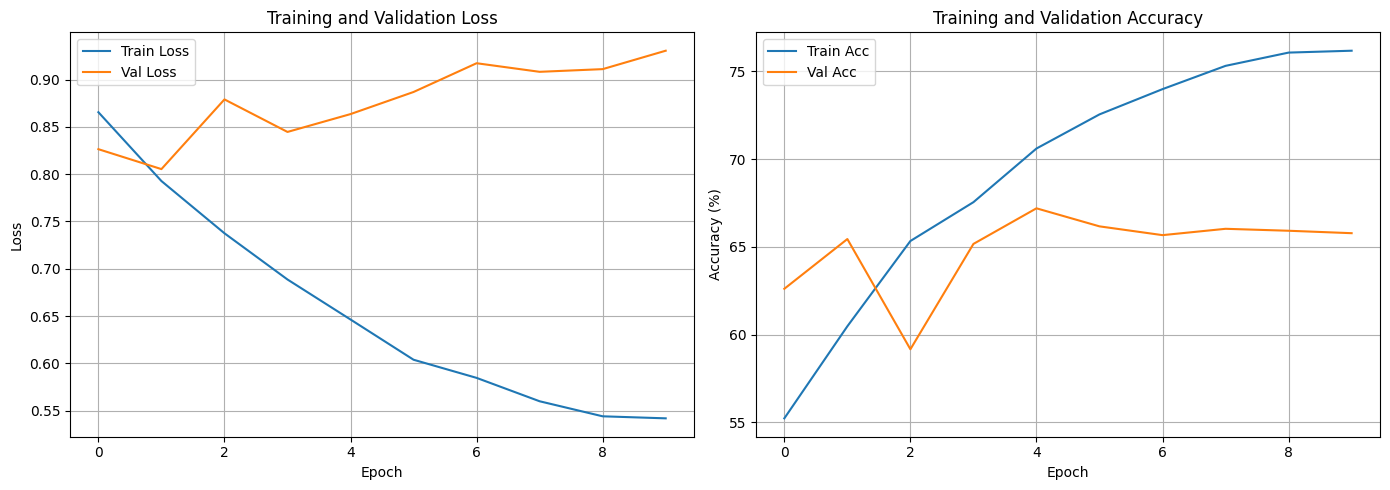

In [21]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/training_history_combined.png', dpi=150)
plt.show()

In [22]:
# Load best model for evaluation
model.load_state_dict(torch.load('/content/drive/MyDrive/dataset/best_acl_model_combined.pth'))

# Final evaluation on test set
test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device)
print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")


Test Results:
Test Loss: 0.9431 | Test Accuracy: 64.17%


In [23]:
# Classification Report
label_names = ['Normal', 'Partial', 'Complete']
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names, digits=3))


Classification Report:
              precision    recall  f1-score   support

      Normal      0.781     0.767     0.774      1740
     Partial      0.332     0.390     0.359       860
    Complete      0.724     0.640     0.680      1020

    accuracy                          0.642      3620
   macro avg      0.612     0.599     0.604      3620
weighted avg      0.658     0.642     0.649      3620



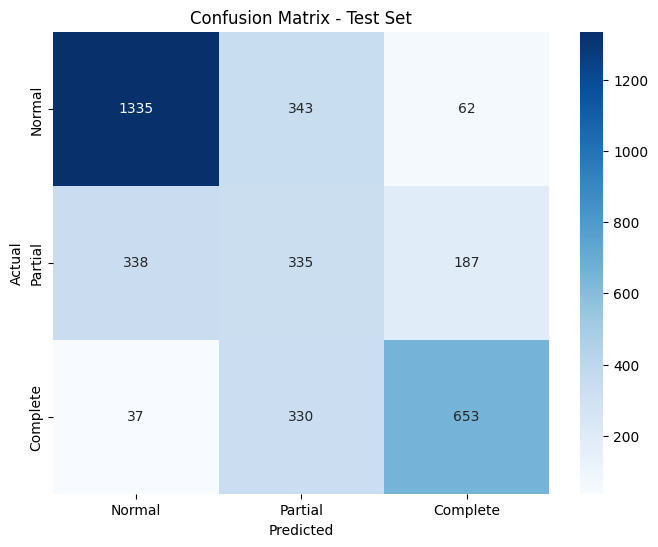


Per-class accuracy:
  Normal: 76.7%
  Partial: 39.0%
  Complete: 64.0%


In [24]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix_combined.png', dpi=150)
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(label_names):
    class_mask = np.array(test_labels) == i
    class_acc = (np.array(test_preds)[class_mask] == i).mean() * 100
    print(f"  {name}: {class_acc:.1f}%")